In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [5]:
data=fetch_california_housing()

In [7]:
print(data.feature_names)
print(data.data.shape)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
(20640, 8)


In [8]:
X=data.data[:,0]
y=data.target
print(X.shape)
print(y.shape)

(20640,)
(20640,)


In [9]:
print(X[:5])
print(y[:5])

[8.3252 8.3014 7.2574 5.6431 3.8462]
[4.526 3.585 3.521 3.413 3.422]


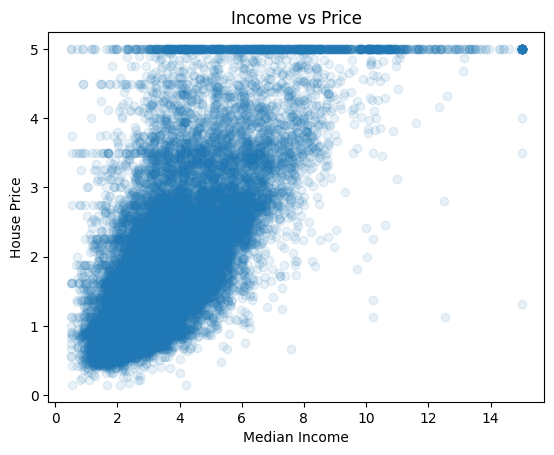

In [10]:
plt.scatter(X,y,alpha=0.1)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Income vs Price")
plt.show()

w = 0.4293
b = 0.3968
final cost = 0.3509


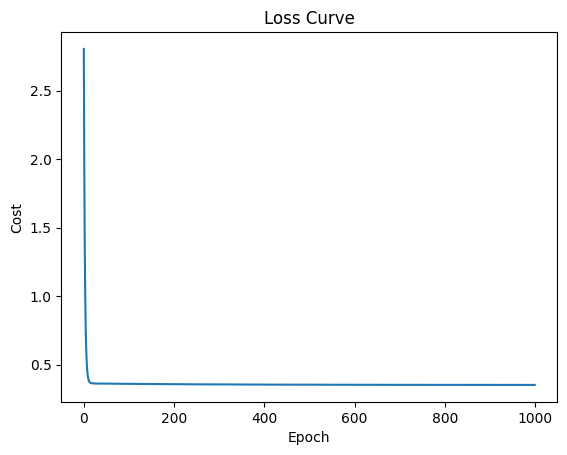

In [17]:
m=len(X)
w=0.0
b=0.0
alpha=0.01
epochs=1000
cost_history = []
for epoch in range(epochs):
    y_hat = w * X + b
    error = y_hat - y

    dw = (1/m) * np.dot(error, X)
    db = (1/m) * np.sum(error)

    w -= alpha * dw
    b -= alpha * db

    cost = (1/(2*m)) * np.sum(error**2)
    cost_history.append(cost)

print(f"w = {w:.4f}")
print(f"b = {b:.4f}")
print(f"final cost = {cost_history[-1]:.4f}")
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Loss Curve")
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X.reshape(-1, 1), y)   

print(f"w = {model.coef_[0]:.4f}")
print(f"b = {model.intercept_:.4f}")

w = 0.4179
b = 0.4509


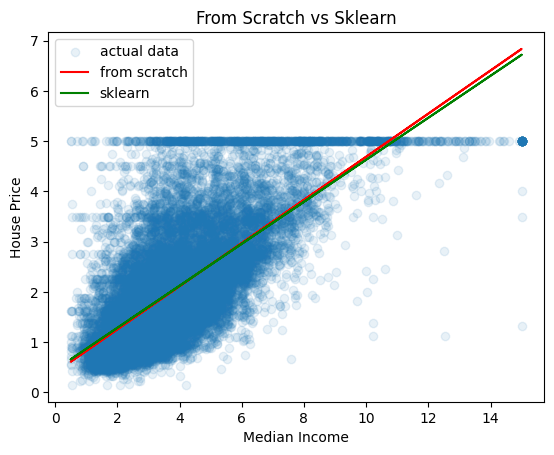

In [18]:

y_hat_scratch = w * X + b                          
y_hat_sklearn = model.predict(X.reshape(-1, 1)) 


plt.scatter(X, y, alpha=0.1, label="actual data")
plt.plot(X, y_hat_scratch, color="red", label="from scratch")
plt.plot(X, y_hat_sklearn, color="green", label="sklearn")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.legend()
plt.title("From Scratch vs Sklearn")
plt.show()

In [19]:
from sklearn.metrics import r2_score

r2_scratch = r2_score(y, y_hat_scratch)
r2_sklearn = r2_score(y, y_hat_sklearn)

print(f"R² from scratch: {r2_scratch:.4f}")
print(f"R² sklearn:      {r2_sklearn:.4f}")

R² from scratch: 0.4730
R² sklearn:      0.4734
